CSV file not found.
Creating sample diabetes time-series data for demonstration...


First 5 Rows:
      Glucose
0  122.483571
1  121.438047
2  127.406312
3  133.643756
4  126.461686

Dataset Information:
Number of observations: 200


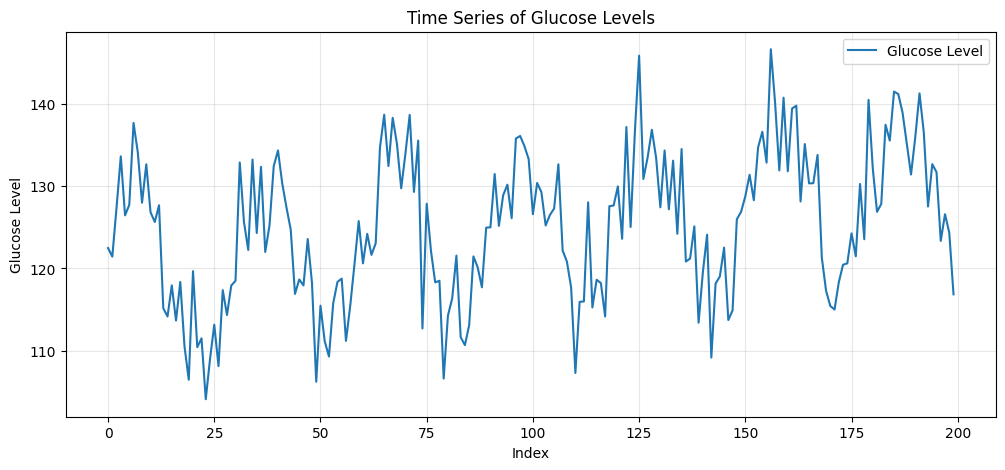

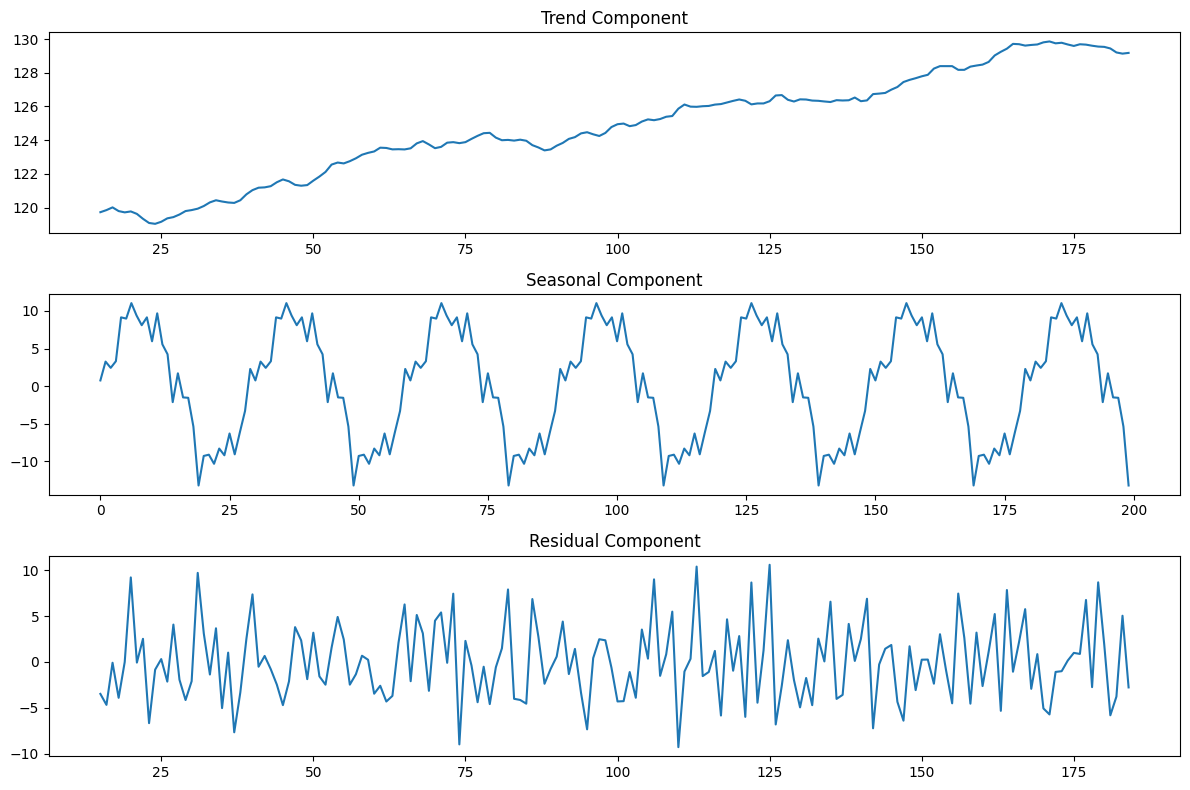

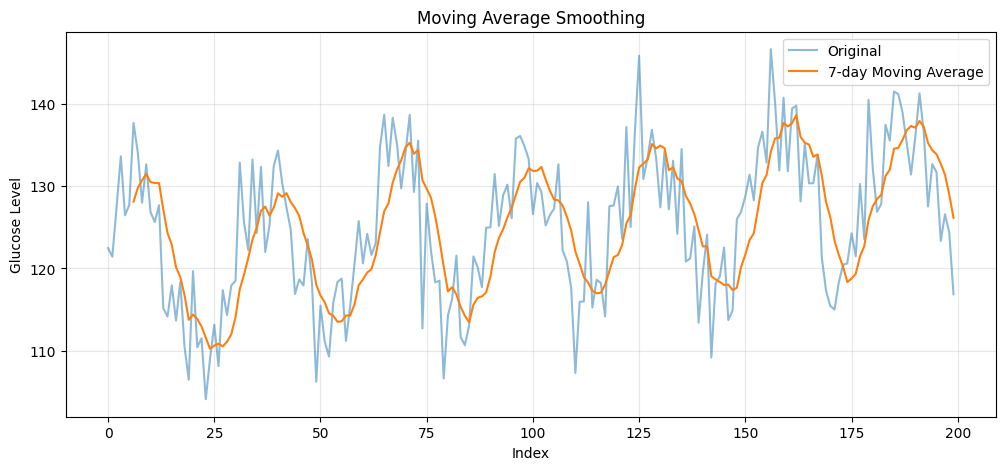


ARIMA Model
-------------------------
Training samples: 160
Testing samples : 40

Forecast Results:
       Actual    Forecast
0  131.827047  137.458583
1  139.457324  138.750277
2  139.811534  138.040855
3  128.154910  137.170247
4  135.137204  138.871694
5  130.355362  137.741974
6  130.372892  138.106440
7  133.808558  138.092671
8  121.337418  137.913738
9  117.292333  138.215162


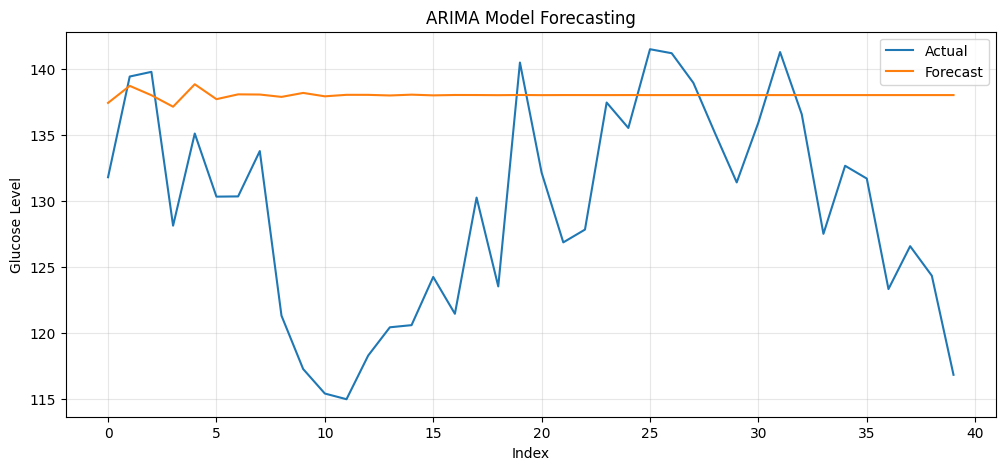


Experiment Completed Successfully!


In [1]:
# ============================================================
# Experiment: Time Series Analysis and ARIMA Forecasting
# ============================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

# ------------------------------------------------------------
# Load the Dataset
# ------------------------------------------------------------

file_name = "diabetes9.csv"

if os.path.exists(file_name):

    diabetes_data = pd.read_csv(file_name)
    print("Dataset loaded successfully!")

else:

    print("CSV file not found.")
    print("Creating sample diabetes time-series data for demonstration...\n")

    np.random.seed(42)

    n = 200

    glucose = (
        120
        + np.linspace(0, 10, n)
        + 10 * np.sin(np.arange(n) * 2 * np.pi / 30)
        + np.random.normal(0, 5, n)
    )

    diabetes_data = pd.DataFrame({
        "Glucose": glucose
    })

# ------------------------------------------------------------
# Check Required Column
# ------------------------------------------------------------

if "Glucose" not in diabetes_data.columns:

    print("Error: 'Glucose' column not found in the dataset.")

else:

    # Remove missing values
    diabetes_data["Glucose"] = pd.to_numeric(
        diabetes_data["Glucose"],
        errors="coerce"
    )

    diabetes_data.dropna(
        subset=["Glucose"],
        inplace=True
    )

    # Reset index
    diabetes_data.reset_index(
        drop=True,
        inplace=True
    )

    # --------------------------------------------------------
    # Check and Preview the Data
    # --------------------------------------------------------

    print("\nFirst 5 Rows:")
    print(diabetes_data.head())

    print("\nDataset Information:")
    print(f"Number of observations: {len(diabetes_data)}")

    # --------------------------------------------------------
    # Plot Time Series Data
    # --------------------------------------------------------

    plt.figure(figsize=(12, 5))

    plt.plot(
        diabetes_data["Glucose"],
        label="Glucose Level"
    )

    plt.xlabel("Index")
    plt.ylabel("Glucose Level")
    plt.title("Time Series of Glucose Levels")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

    # --------------------------------------------------------
    # Time Series Decomposition
    # --------------------------------------------------------

    # At least 2 complete periods are required
    period = 30

    if len(diabetes_data) >= period * 2:

        decomposition = seasonal_decompose(
            diabetes_data["Glucose"],
            model="additive",
            period=period
        )

        fig, axes = plt.subplots(
            3,
            1,
            figsize=(12, 8)
        )

        decomposition.trend.plot(
            ax=axes[0],
            title="Trend Component"
        )

        decomposition.seasonal.plot(
            ax=axes[1],
            title="Seasonal Component"
        )

        decomposition.resid.plot(
            ax=axes[2],
            title="Residual Component"
        )

        plt.tight_layout()
        plt.show()

    else:

        print(
            "\nNot enough data for seasonal decomposition "
            "with period = 30."
        )

    # --------------------------------------------------------
    # Moving Average Smoothing
    # --------------------------------------------------------

    diabetes_data["Glucose_MA"] = (
        diabetes_data["Glucose"]
        .rolling(window=7)
        .mean()
    )

    plt.figure(figsize=(12, 5))

    plt.plot(
        diabetes_data["Glucose"],
        label="Original",
        alpha=0.5
    )

    plt.plot(
        diabetes_data["Glucose_MA"],
        label="7-day Moving Average"
    )

    plt.xlabel("Index")
    plt.ylabel("Glucose Level")
    plt.title("Moving Average Smoothing")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

    # --------------------------------------------------------
    # Build ARIMA Model
    # --------------------------------------------------------

    train_size = int(
        len(diabetes_data) * 0.8
    )

    train = diabetes_data["Glucose"][:train_size]
    test = diabetes_data["Glucose"][train_size:]

    print("\nARIMA Model")
    print("-------------------------")
    print(f"Training samples: {len(train)}")
    print(f"Testing samples : {len(test)}")

    # ARIMA(p,d,q) = ARIMA(5,1,0)
    model = ARIMA(
        train,
        order=(5, 1, 0)
    )

    fitted_model = model.fit()

    # --------------------------------------------------------
    # Forecast Future Glucose Levels
    # --------------------------------------------------------

    forecast = fitted_model.forecast(
        steps=len(test)
    )

    # --------------------------------------------------------
    # Display Forecast Values
    # --------------------------------------------------------

    forecast_df = pd.DataFrame({
        "Actual": test.values,
        "Forecast": forecast.values
    })

    print("\nForecast Results:")
    print(forecast_df.head(10))

    # --------------------------------------------------------
    # Plot Forecast vs Actual Data
    # --------------------------------------------------------

    plt.figure(figsize=(12, 5))

    plt.plot(
        range(len(test)),
        test.values,
        label="Actual"
    )

    plt.plot(
        range(len(test)),
        forecast.values,
        label="Forecast"
    )

    plt.xlabel("Index")
    plt.ylabel("Glucose Level")
    plt.title("ARIMA Model Forecasting")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

    # --------------------------------------------------------
    # Final Message
    # --------------------------------------------------------

    print("\nExperiment Completed Successfully!")